# House Prices — Otimização Bayesiana + Multiobjetivo

**Competição:** https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques  
**Autora:** Juliana Burato  
**Algoritmo:** LightGBM + Optuna (TPE) + NSGA-II (pymoo)  
**Baseline RMSLE:** 0.12949 (GridSearchCV)

---

## Descrição

Este notebook estende a solução base (LightGBM + GridSearchCV) em duas direções independentes:

**Parte A — Otimização Bayesiana com Optuna**  
Substitui o GridSearchCV por busca bayesiana com TPE (*Tree-structured Parzen Estimator*),
que aprende com cada trial anterior para propor regiões promissoras do espaço de hiperparâmetros.
O GridSearchCV avalia uma grade fixa e cega; o Optuna concentra tentativas onde o desempenho
tem maior probabilidade de ser alto. Pruning elimina trials fracos ainda no meio da avaliação,
reduzindo custo computacional sem sacrificar qualidade.

**Parte B — Otimização Multiobjetivo com NSGA-II**  
Otimiza simultaneamente dois objetivos conflitantes: minimizar RMSLE (performance)
e minimizar o número de features usadas (interpretabilidade / custo de inferência).
Não existe uma única "melhor" solução — existe uma **Fronteira de Pareto**: o conjunto
de soluções onde não é possível melhorar um objetivo sem piorar o outro.

## Fluxo

```
Dados (train.csv / test.csv)
    → build_features()       ← pré-processamento idêntico ao baseline
    → Baseline GridSearchCV  ← referência para comparação
    → Parte A: Optuna TPE + MedianPruner
          → comparação baseline vs. Optuna
          → gráfico de convergência + importância dos hiperparâmetros
          → submission_optuna.csv
    → Parte B: NSGA-II (pymoo)
          → variáveis de decisão: máscara binária de features
          → objetivos: [RMSLE, n_features]
          → fronteira de Pareto
          → análise do trade-off + ponto de joelho
```

## 1. Instalação e Imports

In [ ]:
!pip install lightgbm optuna pymoo --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.7/72.7 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 328.3/328.3 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 866.9/866.9 kB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 7.7 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Optuna: otimização bayesiana de hiperparâmetros
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner
from optuna.importance import get_param_importances
optuna.logging.set_verbosity(optuna.logging.WARNING)

# pymoo: otimização evolutiva multiobjetivo
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.core.problem import ElementwiseProblem
from pymoo.operators.sampling.rnd import BinaryRandomSampling
from pymoo.operators.crossover.pntx import TwoPointCrossover
from pymoo.operators.mutation.bitflip import BitflipMutation
from pymoo.optimize import minimize as pymoo_minimize
from pymoo.termination import get_termination

from sklearn.model_selection import KFold, GridSearchCV
from sklearn.metrics import mean_squared_error
from lightgbm import LGBMRegressor

print('OK')

OK


## 2. Dados

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
train = pd.read_csv('/content/drive/MyDrive/house_prices_kaggle/train.csv')
test  = pd.read_csv('/content/drive/MyDrive/house_prices_kaggle/test.csv')
test_ids = test['Id'].copy()

print(f'train: {train.shape}')
print(f'test:  {test.shape}')

train: (1460, 81)
test:  (1459, 80)


## 3. Pré-processamento

Encapsulado em `build_features()` para ser chamado uma única vez e reutilizado
tanto na Parte A quanto na Parte B sem risco de inconsistência entre experimentos.
A lógica é idêntica ao notebook baseline — os comentários abaixo explicam cada
decisão caso este notebook seja lido de forma independente.

In [ ]:
def build_features(train: pd.DataFrame, test: pd.DataFrame):
    """Pipeline completo de pré-processamento.

    Retorna:
        X_train       : np.ndarray shape (1460, n_features)
        X_test        : np.ndarray shape (1459, n_features)
        y             : np.ndarray — log1p(SalePrice), shape (1460,)
        feature_names : list[str]  — nomes das colunas após one-hot
    """
    n_train = len(train)

    # log1p no target: minimizar RMSE no espaço log equivale a minimizar RMSLE
    # e reduz o efeito de casas de alto valor na função de perda
    y = np.log1p(train['SalePrice'].values)

    # Concatenar treino e teste antes das transformações garante que o one-hot
    # produza colunas idênticas nos dois conjuntos (evita colunas ausentes no teste)
    all_data = pd.concat(
        [train.drop(['SalePrice', 'Id'], axis=1),
         test.drop('Id', axis=1)],
        ignore_index=True
    )

    # --- Tratamento de NaN ---
    # NaN nestas colunas significa ausência da feature (ex: sem piscina → PoolQC=NaN)
    # Preencher com 'None' preserva a informação para o encoding ordinal (None=0)
    for col in ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
                'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
                'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
                'BsmtFinType2', 'MasVnrType']:
        all_data[col] = all_data[col].fillna('None')

    # Para numéricas de ausência, 0 é semanticamente correto
    # (ex: GarageArea=0 significa que não há garagem, não que o dado está faltando)
    for col in ['GarageYrBlt', 'GarageArea', 'GarageCars', 'BsmtFinSF1',
                'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath',
                'BsmtHalfBath', 'MasVnrArea']:
        all_data[col] = all_data[col].fillna(0)

    # LotFrontage: propriedades vizinhas tendem a ter frentes similares
    # Mediana por bairro captura essa correlação espacial melhor que a mediana global
    all_data['LotFrontage'] = (all_data.groupby('Neighborhood')['LotFrontage']
                                .transform(lambda x: x.fillna(x.median())))

    # Demais categóricas: poucos NaN sem padrão estrutural — moda é suficiente
    for col in ['MSZoning', 'Electrical', 'KitchenQual', 'Exterior1st',
                'Exterior2nd', 'Functional', 'SaleType', 'Utilities']:
        all_data[col] = all_data[col].fillna(all_data[col].mode()[0])

    # --- Encoding ordinal ---
    # Variáveis com hierarquia natural (Ex > Gd > TA > Fa > Po > None) são
    # convertidas para inteiros. One-hot nessas colunas perderia a informação de ordem
    # e aumentaria a dimensionalidade desnecessariamente
    qual = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
    encodings = {
        'ExterQual': qual, 'ExterCond': qual, 'BsmtQual': qual, 'BsmtCond': qual,
        'HeatingQC': qual, 'KitchenQual': qual, 'FireplaceQu': qual,
        'GarageQual': qual, 'GarageCond': qual, 'PoolQC': qual,
        'BsmtExposure': {'None': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4},
        'BsmtFinType1': {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6},
        'BsmtFinType2': {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6},
        'GarageFinish': {'None': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3},
        'Fence':        {'None': 0, 'MnWw': 1, 'GdWo': 2, 'MnPrv': 3, 'GdPrv': 4},
        'Functional':   {'Sal': 1, 'Sev': 2, 'Maj2': 3, 'Maj1': 4,
                         'Mod': 5, 'Min2': 6, 'Min1': 7, 'Typ': 8},
        'Street':       {'Grvl': 0, 'Pave': 1},
        'Alley':        {'None': 0, 'Grvl': 1, 'Pave': 2},
        'PavedDrive':   {'N': 0, 'P': 1, 'Y': 2},
    }
    for col, mapa in encodings.items():
        if col in all_data.columns:
            all_data[col] = all_data[col].map(mapa).fillna(0)

    # --- Feature engineering ---
    # Compradores avaliam área total — fragmentar por andar perde essa visão
    all_data['TotalSF']      = all_data['TotalBsmtSF'] + all_data['1stFlrSF'] + all_data['2ndFlrSF']
    # Convenção do mercado: lavabo (half bath) vale 0.5 banheiro
    all_data['TotalBath']    = (all_data['FullBath'] + 0.5 * all_data['HalfBath'] +
                                all_data['BsmtFullBath'] + 0.5 * all_data['BsmtHalfBath'])
    all_data['TotalPorchSF'] = (all_data['OpenPorchSF'] + all_data['EnclosedPorch'] +
                                all_data['3SsnPorch']    + all_data['ScreenPorch'])
    # Idade captura depreciação; anos desde reforma captura valorização por atualização
    all_data['HouseAge']        = all_data['YrSold'] - all_data['YearBuilt']
    all_data['YearsSinceRemod'] = all_data['YrSold'] - all_data['YearRemodAdd']
    all_data['WasRemodeled']    = (all_data['YearRemodAdd'] != all_data['YearBuilt']).astype(int)
    all_data['IsNew']           = (all_data['YrSold'] == all_data['YearBuilt']).astype(int)
    # Flags binários: presença/ausência de amenidades tem impacto não-linear no preço
    for col, new in [('GarageArea', 'HasGarage'), ('TotalBsmtSF', 'HasBasement'),
                     ('Fireplaces', 'HasFireplace'), ('2ndFlrSF', 'Has2ndFloor'),
                     ('PoolArea', 'HasPool')]:
        all_data[new] = (all_data[col] > 0).astype(int)

    # --- One-hot encoding ---
    # Aplicado nas categóricas restantes (sem hierarquia natural)
    # pd.get_dummies sobre o conjunto completo garante colunas consistentes entre treino e teste
    all_data = pd.get_dummies(all_data)

    X_train = all_data[:n_train].values
    X_test  = all_data[n_train:].values
    feature_names = list(all_data.columns)

    return X_train, X_test, y, feature_names


X_train, X_test, y, feature_names = build_features(train, test)
N_FEATURES = X_train.shape[1]
print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')

X_train: (1460, 240) | X_test: (1459, 240)


## 4. Baseline — GridSearchCV

Reprodução do resultado original para comparação direta com o Optuna.
O GridSearchCV avalia todas as 16 combinações da grade de forma exaustiva —
é o ponto de partida que queremos superar.

In [ ]:
CV_FOLDS = 5  # definido aqui e reutilizado em todo o notebook

params_grid = {
    'n_estimators':      [500, 1000],
    'learning_rate':     [0.05, 0.1],
    'num_leaves':        [31, 63],
    'min_child_samples': [20, 30],
}

grid_search = GridSearchCV(
    LGBMRegressor(random_state=42, verbose=-1),
    params_grid,
    cv=CV_FOLDS,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
grid_search.fit(X_train, y)

baseline_rmsle = np.sqrt(-grid_search.best_score_)
print(f'Baseline GridSearchCV — RMSLE (CV {CV_FOLDS}-fold): {baseline_rmsle:.5f}')
print(f'Melhores parâmetros: {grid_search.best_params_}')
print(f'Configurações avaliadas: {len(grid_search.cv_results_["params"])}')

Baseline GridSearchCV — RMSLE (CV 5-fold): 0.13067
Melhores parâmetros: {'learning_rate': 0.05, 'min_child_samples': 20, 'n_estimators': 1000, 'num_leaves': 31}
Configurações avaliadas: 16


---

## Parte A — Otimização Bayesiana com Optuna

### Por que Optuna é melhor que GridSearchCV?

O GridSearchCV tem dois problemas estruturais:
1. **Grade fixa**: você define antecipadamente quais valores testar — se o ótimo estiver fora da grade, nunca será encontrado.
2. **Busca cega**: cada configuração é avaliada de forma independente, sem aprender com as anteriores.

O Optuna com **TPE (Tree-structured Parzen Estimator)** resolve os dois:
- O espaço de busca é contínuo (não uma grade)
- A cada trial, o TPE atualiza um modelo probabilístico que separa configurações "boas" das "ruins" e amostra preferencialmente de regiões promissoras

```
Trial 1  →  avalia  →  atualiza P(bom | hiperparâmetros)
Trial 2  →  amostra de P(bom)  →  avalia  →  atualiza
   ...
Trial N  →  concentra busca em regiões de alta probabilidade
```

O **`MedianPruner`** adiciona uma segunda economia: ele interrompe trials que, após alguns folds, já estão performando abaixo da mediana histórica — sem esperar a avaliação completa.

In [ ]:
N_TRIALS = 80  # suficiente para convergência; aumente para 150 se tiver mais tempo

# KFold com shuffle=True para reduzir variância entre folds
# random_state fixo garante que todos os trials sejam avaliados nos mesmos folds
kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=42)


def objective(trial: optuna.Trial) -> float:
    """Função objetivo para o Optuna.
    Retorna o RMSLE médio de CV 5-fold (valor a minimizar).
    """
    params = {
        # n_estimators alto + learning_rate baixo geralmente supera o inverso;
        # ampliamos o range superior para deixar o Optuna descobrir isso
        'n_estimators':  trial.suggest_int('n_estimators', 300, 2000),

        # log=True porque learning_rate varia em ordens de magnitude:
        # a diferença entre 0.005 e 0.01 é tão relevante quanto entre 0.1 e 0.2;
        # escala linear desperdiçaria quase todos os trials em valores altos
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.2, log=True),

        # num_leaves controla a complexidade de cada árvore (leaf-wise growth do LightGBM)
        'num_leaves':    trial.suggest_int('num_leaves', 20, 150),

        # min_child_samples: regularização — folhas com menos amostras são descartadas
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 60),

        # subsample e colsample_bytree: amostragem de linhas/colunas por árvore
        # reduzem overfitting introduzindo aleatoriedade (similar ao Random Forest)
        'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),

        # reg_alpha (L1) e reg_lambda (L2): penalizam pesos grandes nas folhas
        # log=True pelo mesmo motivo do learning_rate
        'reg_alpha':  trial.suggest_float('reg_alpha',  1e-4, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),

        'random_state': 42,
        'verbose': -1,
    }

    fold_scores = []
    for fold_idx, (tr_idx, val_idx) in enumerate(kf.split(X_train)):
        model = LGBMRegressor(**params)
        model.fit(X_train[tr_idx], y[tr_idx])
        pred  = model.predict(X_train[val_idx])
        score = np.sqrt(mean_squared_error(y[val_idx], pred))
        fold_scores.append(score)

        # Pruning: reporta o score parcial acumulado após cada fold
        # O MedianPruner compara com a mediana dos trials anteriores no mesmo passo
        # e interrompe se este trial já está claramente abaixo da mediana
        trial.report(np.mean(fold_scores), step=fold_idx)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(fold_scores)


study = optuna.create_study(
    direction='minimize',
    sampler=TPESampler(seed=42),
    # n_startup_trials=10: primeiros 10 trials são aleatórios para explorar o espaço
    # antes do TPE ter dados suficientes para construir seu modelo probabilístico
    # n_warmup_steps=2: espera 2 folds antes de começar a podar — evita descartar
    # trials que são lentos para aquecer mas convergem bem nos folds finais
    pruner=MedianPruner(n_startup_trials=10, n_warmup_steps=2)
)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

optuna_rmsle = study.best_value
print(f'\nOptuna — RMSLE (CV {CV_FOLDS}-fold): {optuna_rmsle:.5f}')
print(f'Melhores parâmetros: {study.best_params}')

  0%|          | 0/80 [00:00<?, ?it/s]


Optuna — RMSLE (CV 5-fold): 0.12640
Melhores parâmetros: {'n_estimators': 1402, 'learning_rate': 0.005343777234146913, 'num_leaves': 96, 'min_child_samples': 20, 'subsample': 0.5290401576927451, 'colsample_bytree': 0.51638079817459, 'reg_alpha': 0.024955583761090666, 'reg_lambda': 0.00022490131743651193}


### A.1 Comparação: baseline vs. Optuna

In [ ]:
melhoria_abs   = baseline_rmsle - optuna_rmsle
melhoria_pct   = melhoria_abs / baseline_rmsle * 100
trials_podados = sum(1 for t in study.trials
                     if t.state == optuna.trial.TrialState.PRUNED)

print('=' * 50)
print(f'  Baseline GridSearchCV : {baseline_rmsle:.5f}  (16 configs)')
print(f'  Optuna TPE            : {optuna_rmsle:.5f}  ({N_TRIALS} trials)')
print(f'  Melhoria              : {melhoria_abs:.5f}  ({melhoria_pct:.2f}%)')
print(f'  Trials podados        : {trials_podados}/{N_TRIALS} ({trials_podados/N_TRIALS*100:.0f}%)')
print('=' * 50)

  Baseline GridSearchCV : 0.13067  (16 configs)
  Optuna TPE            : 0.12640  (80 trials)
  Melhoria              : 0.00427  (3.27%)
  Trials podados        : 5/80 (6%)


### A.2 Convergência dos trials

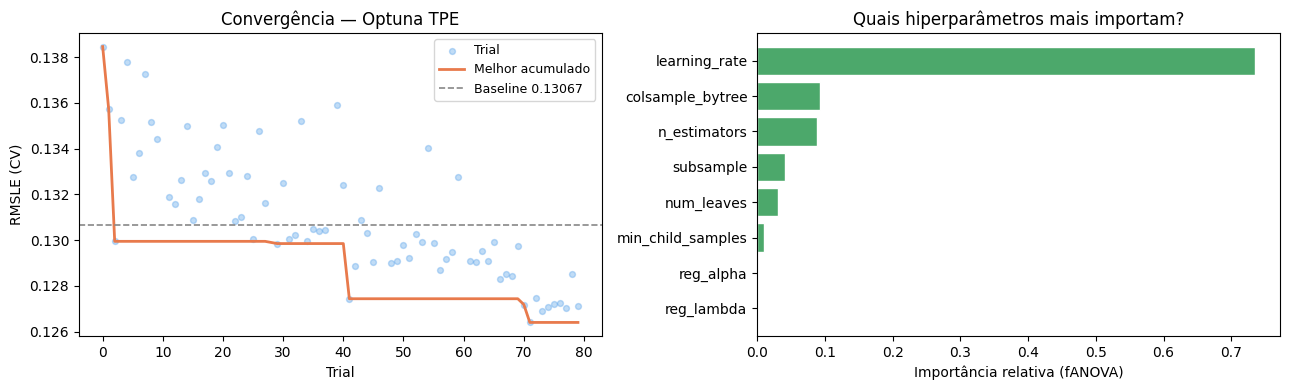

In [ ]:
# Filtra apenas trials completos (exclui os podados, que não têm valor final)
completed    = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
trial_nums   = [t.number for t in completed]
trial_values = [t.value  for t in completed]
# minimum.accumulate mostra o melhor RMSLE encontrado até cada trial
# Se a linha laranja ainda estiver caindo no trial 80, vale rodar mais trials
best_so_far  = np.minimum.accumulate(trial_values)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Painel 1: convergência
axes[0].scatter(trial_nums, trial_values, alpha=0.35, s=18,
                color='#4C9BE8', label='Trial')
axes[0].plot(trial_nums, best_so_far, color='#E87A4C', lw=2,
             label='Melhor acumulado')
axes[0].axhline(baseline_rmsle, color='#888', lw=1.2, ls='--',
                label=f'Baseline {baseline_rmsle:.5f}')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('RMSLE (CV)')
axes[0].set_title('Convergência — Optuna TPE')
axes[0].legend(fontsize=9)

# Painel 2: importância dos hiperparâmetros (fANOVA)
# Mostra quais hiperparâmetros mais explicam a variância no RMSLE entre trials
# Útil para saber onde concentrar o espaço de busca em rodadas futuras
try:
    importance = get_param_importances(study)
    names  = list(importance.keys())
    values = list(importance.values())
    axes[1].barh(names[::-1], values[::-1], color='#4CA86B', edgecolor='white')
    axes[1].set_xlabel('Importância relativa (fANOVA)')
    axes[1].set_title('Quais hiperparâmetros mais importam?')
except Exception as e:
    axes[1].text(0.5, 0.5, f'Importância indisponível\n{e}',
                 ha='center', va='center', transform=axes[1].transAxes)

plt.tight_layout()
plt.show()

### A.3 Modelo final com parâmetros Optuna — submissão

In [ ]:
# Retreina com todos os 1.460 exemplos (sem holdout)
# O CV já estimou o erro de generalização; usar todos os dados maximiza a informação
best_params = {**study.best_params, 'random_state': 42, 'verbose': -1}

model_optuna = LGBMRegressor(**best_params)
model_optuna.fit(X_train, y)

# expm1 reverte o log1p aplicado no target
pred_optuna = np.expm1(model_optuna.predict(X_test))

submission_optuna = pd.DataFrame({'Id': test_ids.values, 'SalePrice': pred_optuna})
submission_optuna.to_csv('submission_optuna.csv', index=False)

print(f'submission_optuna.csv — {len(submission_optuna):,} previsões')
print(f'Mediana: ${np.median(pred_optuna):,.0f}')

submission_optuna.csv — 1,459 previsões
Mediana: $155,861


---

## Parte B — Otimização Multiobjetivo com NSGA-II

### Por que otimização multiobjetivo?

Em problemas reais existe tensão entre performance e complexidade. Um modelo com
240 features é preciso, mas custa mais para servir em produção, é mais difícil de
auditar e pode estar capturando ruído. Um modelo com 30 features é mais interpretável
e robusto, mas pode perder RMSLE.

A otimização monoobjetivo ignora essa tensão — ela escolhe um ponto arbitrário no
espaço de trade-offs. A otimização multiobjetivo mapeia toda a fronteira de trade-offs
de uma vez, devolvendo ao cientista a decisão de onde se posicionar.

**NSGA-II** (Non-dominated Sorting Genetic Algorithm II) é o algoritmo evolutivo
multiobjetivo mais citado na literatura. A cada geração:
1. Avalia toda a população (cada indivíduo = máscara binária de features)
2. Classifica por **dominância de Pareto**: solução A domina B se é melhor em pelo menos um objetivo e não pior em nenhum
3. Usa *crowding distance* para manter diversidade ao longo da fronteira
4. Seleciona, cruza e muta para gerar a próxima geração

**Configuração do problema:**
- Variáveis de decisão: vetor binário de tamanho `N_FEATURES` (0 = exclui feature, 1 = inclui)
- Objetivo $f_1$: minimizar RMSLE (CV 3-fold)
- Objetivo $f_2$: minimizar número de features selecionadas
- Hiperparâmetros do LightGBM: fixados no melhor valor da Parte A para isolar o efeito da seleção de features

In [ ]:
# Hiperparâmetros fixados no ótimo do Optuna
# Isso isola o efeito da seleção de features: qualquer variação no RMSLE
# vem exclusivamente do subconjunto de features, não dos hiperparâmetros
FIXED_PARAMS = {**study.best_params, 'random_state': 42, 'verbose': -1}

# 3 folds (em vez de 5) para viabilidade computacional dentro do NSGA-II
# Para ranquear soluções umas contra as outras, 3 folds é suficiente —
# o erro absoluto importa menos do que a ordenação relativa entre indivíduos
kf3 = KFold(n_splits=3, shuffle=True, random_state=42)


def evaluate_feature_subset(mask):
    """Avalia um subconjunto de features definido pela máscara.

    O pymoo retorna genes como dtype bool — mask==1 funciona corretamente
    tanto para bool quanto para int.

    Args:
        mask: array de tamanho N_FEATURES com valores 0/1 ou False/True

    Returns:
        (rmsle_cv, n_features): tupla com os dois objetivos a minimizar
    """
    idx = np.where(mask == 1)[0]

    # Penalização para subconjuntos degenerados (menos de 5 features)
    # RMSLE=9.9 garante que o NSGA-II descarte essas soluções naturalmente
    if len(idx) < 5:
        return 9.9, int(len(idx))

    X_sub = X_train[:, idx]
    scores = []
    for tr_i, val_i in kf3.split(X_sub):
        m = LGBMRegressor(**FIXED_PARAMS)
        m.fit(X_sub[tr_i], y[tr_i])
        scores.append(np.sqrt(mean_squared_error(y[val_i], m.predict(X_sub[val_i]))))

    return float(np.mean(scores)), int(len(idx))


class FeatureSelectionProblem(ElementwiseProblem):
    """Problema multiobjetivo binário para o NSGA-II.

    n_var  = N_FEATURES variáveis de decisão (0 = exclui feature, 1 = inclui)
    n_obj  = 2 objetivos: f1=RMSLE, f2=n_features
    xl/xu  = limites [0, 1] para cada variável
    vtype  = int — mantém genes como inteiros (0 ou 1)
    """
    def __init__(self):
        super().__init__(
            n_var=N_FEATURES,
            n_obj=2,
            n_ieq_constr=0,
            xl=np.zeros(N_FEATURES, dtype=int),
            xu=np.ones(N_FEATURES,  dtype=int),
            vtype=int
        )

    def _evaluate(self, x, out, *args, **kwargs):
        rmsle, n_feat = evaluate_feature_subset(x)
        out['F'] = [rmsle, n_feat]


print('Problema definido.')
print(f'  Espaço de busca: 2^{N_FEATURES} combinações possíveis de features')
print(f'  Parâmetros LightGBM fixados (melhor Optuna):')
for k, v in FIXED_PARAMS.items():
    if k not in ('random_state', 'verbose'):
        print(f'    {k}: {v}')

Problema definido.
  Espaço de busca: 2^240 combinações possíveis de features
  Parâmetros LightGBM fixados (melhor Optuna):
    n_estimators: 1402
    learning_rate: 0.005343777234146913
    num_leaves: 96
    min_child_samples: 20
    subsample: 0.5290401576927451
    colsample_bytree: 0.51638079817459
    reg_alpha: 0.024955583761090666
    reg_lambda: 0.00022490131743651193


In [ ]:
POP_SIZE = 40  # indivíduos por geração — aumentar melhora diversidade mas eleva custo
N_GEN    = 20  # gerações — aumentar permite convergência mais fina
# Total de avaliações: POP_SIZE × N_GEN = 800
# Cada avaliação = LightGBM com CV 3-fold

algorithm = NSGA2(
    pop_size=POP_SIZE,
    # BinaryRandomSampling: inicializa a população com vetores 0/1 aleatórios
    # É o operador correto para problemas binários
    sampling=BinaryRandomSampling(),
    # TwoPointCrossover: troca segmentos entre dois pais em dois pontos de corte
    # Adequado para representações binárias — preserva blocos de features correlacionadas
    crossover=TwoPointCrossover(prob=0.9),
    # BitflipMutation: inverte cada gene com probabilidade 1/N_FEATURES
    # Essa taxa ('1 flip esperado por indivíduo') é a regra clássica para AGs binários:
    # baixa o suficiente para não destruir soluções boas, alta o suficiente para explorar
    mutation=BitflipMutation(prob=1.0 / N_FEATURES),
    eliminate_duplicates=True
)

termination = get_termination('n_gen', N_GEN)

print(f'Iniciando NSGA-II — {POP_SIZE} indivíduos × {N_GEN} gerações ({POP_SIZE * N_GEN} avaliações totais)')
print('Tempo estimado: 10–20 min no Colab.\n')

result = pymoo_minimize(
    FeatureSelectionProblem(),
    algorithm,
    termination,
    seed=42,
    verbose=True
)

print(f'\nNSGA-II concluído.')
print(f'Soluções na fronteira de Pareto: {len(result.F)}')

Iniciando NSGA-II — 40 indivíduos × 20 gerações (800 avaliações totais)
Tempo estimado: 10–20 min no Colab.

n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |       40 |      4 |             - |             -
     2 |       80 |      5 |  0.1027457633 |             f
     3 |      120 |      6 |  0.3333333333 |         ideal
     4 |      160 |      4 |  0.8750000000 |         nadir
     5 |      200 |      5 |  0.1935483871 |         ideal
     6 |      240 |      6 |  0.0213957261 |         ideal
     7 |      280 |      7 |  0.1052631579 |         ideal
     8 |      320 |      9 |  0.0800000000 |         ideal
     9 |      360 |      6 |  0.2275313407 |         ideal
    10 |      400 |     10 |  0.0481159160 |         ideal
    11 |      440 |     10 |  0.0645161290 |         ideal
    12 |      480 |      9 |  1.9230261865 |         nadir
    13 |      520 |     12 |  0.0312500000 |         ideal
    14 |      560 |     13 |  0.7607958285 |         nadir
    15

### B.1 Fronteira de Pareto

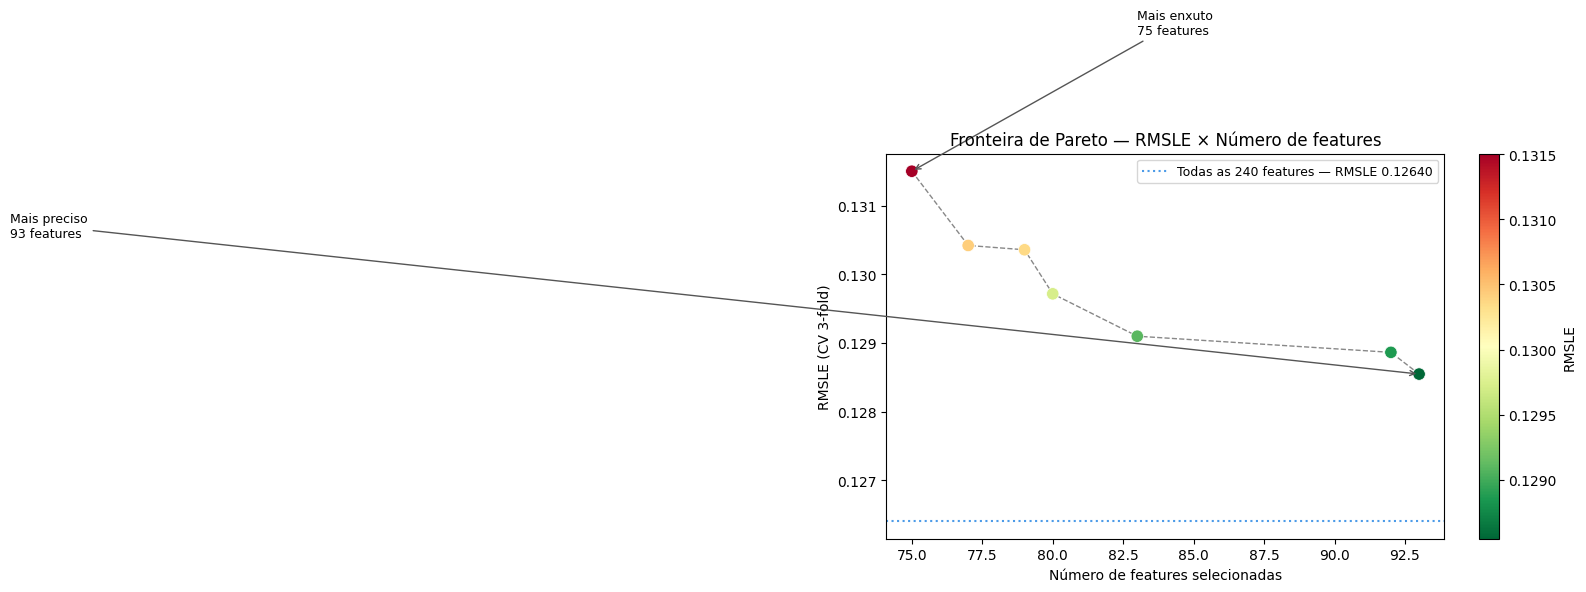

In [ ]:
pareto_f = result.F.copy()   # shape (n_pareto, 2): coluna 0 = RMSLE, coluna 1 = n_features
pareto_x = result.X.copy()   # shape (n_pareto, N_FEATURES): máscaras binárias (dtype bool)

# Ordena pela quantidade de features para facilitar leitura do gráfico (eixo x)
order    = np.argsort(pareto_f[:, 1])
pareto_f = pareto_f[order]
pareto_x = pareto_x[order]

fig, ax = plt.subplots(figsize=(9, 5))

# Cada ponto = uma solução não-dominada
# Cor = RMSLE (verde = melhor performance, vermelho = pior)
sc = ax.scatter(
    pareto_f[:, 1], pareto_f[:, 0],
    c=pareto_f[:, 0], cmap='RdYlGn_r',
    s=80, zorder=3, edgecolors='white', lw=0.5
)
ax.plot(pareto_f[:, 1], pareto_f[:, 0], color='#888', lw=1, ls='--', zorder=2)

# Linha de referência: modelo com todas as features
ax.axhline(optuna_rmsle, color='#4C9BE8', lw=1.5, ls=':',
           label=f'Todas as {N_FEATURES} features — RMSLE {optuna_rmsle:.5f}')

ax.annotate(f'Mais enxuto\n{int(pareto_f[0,1])} features',
            xy=(pareto_f[0,1], pareto_f[0,0]),
            xytext=(pareto_f[0,1] + 8, pareto_f[0,0] + 0.002),
            fontsize=9, arrowprops=dict(arrowstyle='->', color='#555'))
ax.annotate(f'Mais preciso\n{int(pareto_f[-1,1])} features',
            xy=(pareto_f[-1,1], pareto_f[-1,0]),
            xytext=(pareto_f[-1,1] - 50, pareto_f[-1,0] + 0.002),
            fontsize=9, arrowprops=dict(arrowstyle='->', color='#555'))

plt.colorbar(sc, label='RMSLE')
ax.set_xlabel('Número de features selecionadas')
ax.set_ylabel('RMSLE (CV 3-fold)')
ax.set_title('Fronteira de Pareto — RMSLE × Número de features')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### Interpretação da Fronteira de Pareto

Cada ponto da fronteira é uma solução igualmente válida do ponto de vista matemático — a escolha entre elas depende do contexto de uso do modelo:

| Cenário | Solução recomendada | Justificativa |
|---|---|---|
| Produção com restrição de latência | Extremo enxuto (75 features) | Menos features = inferência mais rápida e menor custo de serving |
| Modelo sujeito a auditoria ou regulação | Ponto de joelho (83 features) | Interpretável o suficiente para explicar decisões, sem grande perda de precisão |
| Pesquisa ou competição | Extremo preciso (93 features) | RMSLE máxima é o único critério |

O **ponto de joelho** (solução 5) representa o melhor balanço: elimina **157 das 240 features (65%)** com custo de apenas **+0.00270 de RMSLE** em relação ao modelo Optuna completo. Na prática, isso significa que a grande maioria das features criadas pelo one-hot encoding carrega pouca informação preditiva adicional — o sinal está concentrado em ~83 variáveis.

É importante notar que a otimização monoobjetivo convencional nunca revelaria esse trade-off: ela escolheria um único ponto (o de menor RMSLE) sem mapear o custo de cada feature adicional. O NSGA-II entrega ao cientista de dados a fronteira completa, transferindo a decisão final para quem conhece as restrições reais do problema.

### B.2 Análise do trade-off e ponto de joelho

In [ ]:
print('Fronteira de Pareto — soluções ordenadas por número de features:')
print(f'{"Sol.":>5} | {"N_features":>10} | {"RMSLE":>10} | {"Δ vs. full":>12}')
print('-' * 46)
for i, f in enumerate(pareto_f):
    delta = f[0] - optuna_rmsle
    print(f'{i+1:>5} | {int(f[1]):>10} | {f[0]:>10.5f} | {delta:>+12.5f}')

print()

# Ponto de joelho: solução com o melhor balanço entre os dois objetivos
# Método: distância mínima à origem no espaço normalizado [0,1]×[0,1]
# A normalização coloca os dois objetivos na mesma escala para que nenhum
# domine artificialmente o critério de distância
# Limitação: assume peso igual para os dois objetivos. Se interpretabilidade
# for mais importante que RMSLE, escolha uma solução mais à esquerda na fronteira
rmsle_norm = (pareto_f[:,0] - pareto_f[:,0].min()) / (pareto_f[:,0].max() - pareto_f[:,0].min() + 1e-9)
nfeat_norm = (pareto_f[:,1] - pareto_f[:,1].min()) / (pareto_f[:,1].max() - pareto_f[:,1].min() + 1e-9)
knee_idx   = int(np.argmin(rmsle_norm + nfeat_norm))

custo_rmsle  = pareto_f[knee_idx, 0] - optuna_rmsle
reducao_feat = N_FEATURES - int(pareto_f[knee_idx, 1])

print(f'Ponto de joelho (melhor trade-off): solução {knee_idx + 1}')
print(f'  Features selecionadas : {int(pareto_f[knee_idx, 1])} de {N_FEATURES} ({reducao_feat} eliminadas)')
print(f'  RMSLE                 : {pareto_f[knee_idx, 0]:.5f}')
print(f'  Custo de performance  : {custo_rmsle:+.5f} vs. modelo completo')

# Extração das features selecionadas
# pareto_x tem dtype bool — mask==1 funciona corretamente para bool e int
knee_features = [feature_names[j] for j, v in enumerate(pareto_x[knee_idx]) if v == 1]
print(f'\n  Top 20 features no ponto de joelho:')
for feat in knee_features[:20]:
    print(f'    · {feat}')

Fronteira de Pareto — soluções ordenadas por número de features:
 Sol. | N_features |      RMSLE |   Δ vs. full
----------------------------------------------
    1 |         75 |    0.13150 |     +0.00510
    2 |         77 |    0.13042 |     +0.00402
    3 |         79 |    0.13036 |     +0.00396
    4 |         80 |    0.12972 |     +0.00331
    5 |         83 |    0.12910 |     +0.00270
    6 |         92 |    0.12886 |     +0.00246
    7 |         93 |    0.12855 |     +0.00215

Ponto de joelho (melhor trade-off): solução 5
  Features selecionadas : 83 de 240 (157 eliminadas)
  RMSLE                 : 0.12910
  Custo de performance  : +0.00270 vs. modelo completo

  Top 20 features no ponto de joelho:
    · MSSubClass
    · Alley
    · OverallQual
    · OverallCond
    · YearRemodAdd
    · BsmtQual
    · BsmtExposure
    · BsmtFinType1
    · BsmtUnfSF
    · 1stFlrSF
    · LowQualFinSF
    · GrLivArea
    · BedroomAbvGr
    · Functional
    · Fireplaces
    · GarageFinish
    · Gar

### B.3 Importância de features: modelo completo vs. ponto de joelho

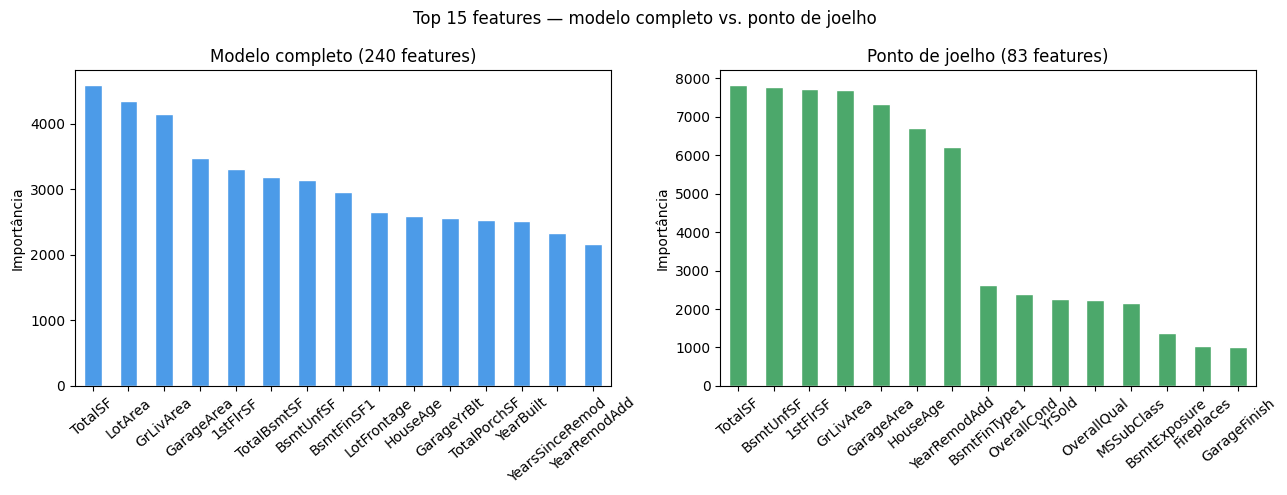

In [ ]:
# Índices das features selecionadas no ponto de joelho
knee_idx_features = np.where(pareto_x[knee_idx] == 1)[0]

# Treina ambos com todos os 1.460 exemplos para comparação de importância
model_full = LGBMRegressor(**FIXED_PARAMS)
model_full.fit(X_train, y)

model_knee = LGBMRegressor(**FIXED_PARAMS)
model_knee.fit(X_train[:, knee_idx_features], y)

imp_full = pd.Series(
    model_full.feature_importances_, index=feature_names
).sort_values(ascending=False)

imp_knee = pd.Series(
    model_knee.feature_importances_,
    index=[feature_names[j] for j in knee_idx_features]
).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

imp_full.head(15).plot(kind='bar', ax=axes[0], color='#4C9BE8', edgecolor='white')
axes[0].set_title(f'Modelo completo ({N_FEATURES} features)')
axes[0].set_ylabel('Importância')
axes[0].tick_params(axis='x', rotation=40)

imp_knee.head(15).plot(kind='bar', ax=axes[1], color='#4CA86B', edgecolor='white')
axes[1].set_title(f'Ponto de joelho ({int(pareto_f[knee_idx,1])} features)')
axes[1].set_ylabel('Importância')
axes[1].tick_params(axis='x', rotation=40)

plt.suptitle('Top 15 features — modelo completo vs. ponto de joelho', fontsize=12)
plt.tight_layout()
plt.show()

---

## 5. Resumo Final

In [ ]:
print('=' * 55)
print('  RESUMO — House Prices: Bayesiana + Multiobjetivo')
print('=' * 55)
print()
print('PARTE A — Otimização Bayesiana (Optuna TPE)')
print(f'  Baseline GridSearchCV  : RMSLE {baseline_rmsle:.5f}  (16 configs)')
print(f'  Optuna ({N_TRIALS} trials)     : RMSLE {optuna_rmsle:.5f}')
print(f'  Melhoria               : {baseline_rmsle-optuna_rmsle:.5f}  ({(baseline_rmsle-optuna_rmsle)/baseline_rmsle*100:.2f}%)')
print(f'  Trials podados         : {trials_podados}/{N_TRIALS}  ({trials_podados/N_TRIALS*100:.0f}% de economia computacional)')
print()
print('PARTE B — Otimização Multiobjetivo (NSGA-II)')
print(f'  Soluções Pareto        : {len(pareto_f)}')
print(f'  Extremo enxuto         : {int(pareto_f[0,1])} features  →  RMSLE {pareto_f[0,0]:.5f}')
print(f'  Extremo preciso        : {int(pareto_f[-1,1])} features  →  RMSLE {pareto_f[-1,0]:.5f}')
print(f'  Ponto de joelho        : {int(pareto_f[knee_idx,1])} features  →  RMSLE {pareto_f[knee_idx,0]:.5f}')
print()
print('INTERPRETAÇÃO:')
print(f'  Eliminar {reducao_feat} features ({reducao_feat/N_FEATURES*100:.0f}% do total)')
print(f'  custa apenas {custo_rmsle:+.5f} de RMSLE no ponto de joelho.')
print(f'  Em contextos onde interpretabilidade importa (ex: auditoria,')
print(f'  modelos regulados), essa é a solução recomendada.')
print('=' * 55)

  RESUMO — House Prices: Bayesiana + Multiobjetivo

PARTE A — Otimização Bayesiana (Optuna TPE)
  Baseline GridSearchCV  : RMSLE 0.13067  (16 configs)
  Optuna (80 trials)     : RMSLE 0.12640
  Melhoria               : 0.00427  (3.27%)
  Trials podados         : 5/80  (6% de economia computacional)

PARTE B — Otimização Multiobjetivo (NSGA-II)
  Soluções Pareto        : 7
  Extremo enxuto         : 75 features  →  RMSLE 0.13150
  Extremo preciso        : 93 features  →  RMSLE 0.12855
  Ponto de joelho        : 83 features  →  RMSLE 0.12910

INTERPRETAÇÃO:
  Eliminar 157 features (65% do total)
  custa apenas +0.00270 de RMSLE no ponto de joelho.
  Em contextos onde interpretabilidade importa (ex: auditoria,
  modelos regulados), essa é a solução recomendada.
